262144


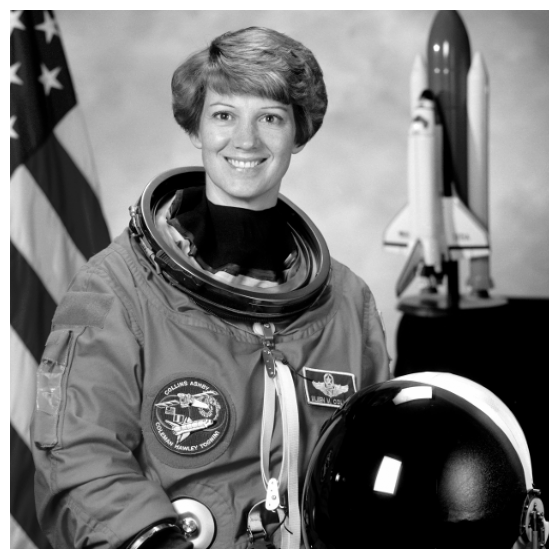

In [1]:
import skimage as si
import skimage.color as sc
import matplotlib.pyplot as plt
import numpy as np
import scipy.signal as ss
from algorithms import Algorithms
import time
import pywt

img = sc.rgb2gray( si.data.astronaut() )

print( np.prod( img.shape ) )

plt.figure( figsize = ( 7, 7 ) )
plt.imshow( img, cmap = plt.cm.gray )
plt.axis( "off" )
plt.show()

In [2]:
N_kernel = 7
kernel = np.full( ( N_kernel, N_kernel ), 1 / ( N_kernel ** 2 ) )

def A( x ):
    return ss.convolve2d( x, kernel, mode = "same" )

def A_transpose( x ):
    return ss.correlate2d( x, kernel, mode = "same" )

def ATA( x ):
    return A_transpose( A( x ) )

In [3]:
#testando se AT é adjunta de A ( y'Ax = x'ATy )

x = np.random.standard_normal( size = img.shape )
y = np.random.standard_normal( size = img.shape )

print( ( y * A( x ) ).sum() )
print( ( x * A_transpose( y ) ).sum() )

#okay

17.56948307131231
17.569483071312316


In [4]:
img_borrada = A( img )


In [19]:
#vendo se H é adjunta de HT (y'Hx = x'HTy) e se HT é a inversa de H

def H( x, wavelet = 'db5' ):
  return pywt.coeffs_to_array( pywt.wavedec2( x, wavelet = wavelet, mode = 'periodization' ) )

def HT( c, wavelet = 'db5' ):
  return pywt.waverec2( pywt.array_to_coeffs( *c, output_format = 'wavedec2' ), wavelet = wavelet, mode = 'periodization' )

Hx = H( x )

print( np.sum( y * Hx[ 0 ] ) )
print( np.sum( x * HT( ( y, Hx[ 1 ] ) ) ) )
print( np.abs( img - HT( H( img ) ) ).sum(  ) )
#para a imagem do café tem esse problema de que o pywt expande o tamanho da imagem, com isso H não é adjunta de HT ( encontrado o problema )
#para a imagem da astronauta tudo da certo

420.7183972020018
420.71839720200194
6.399910360449918e-11


In [6]:
#imagem borrada com ruído
gauss_noise = np.random.normal( 0, 0.01, img.shape )
b = img_borrada + gauss_noise

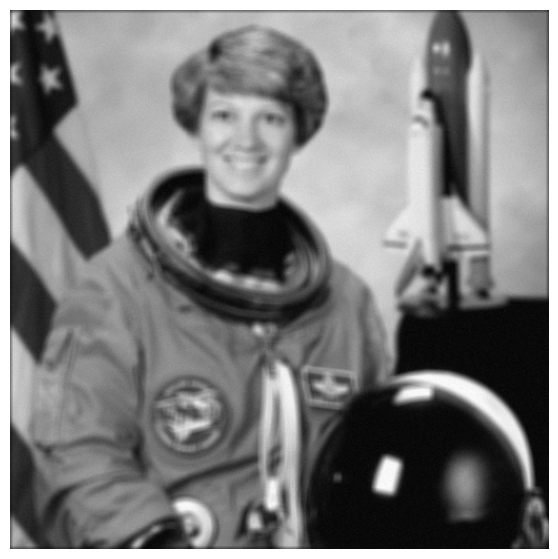

In [7]:
plt.figure( figsize = ( 7, 7 ) )
plt.imshow( b, cmap = plt.cm.gray )
plt.axis( "off" )
plt.show()

In [8]:
def f( x ):
    return 1/2 * ( (A( x ) - b) ** 2 ).sum()

def grad_f( x ):
    return A_transpose( A( x ) - b )

def g( x, wavelet = 'haar' ):
  coeffs = pywt.wavedec2( x, wavelet = wavelet, mode = 'periodization' )
  l1 = 0.0
  for i in coeffs[ 1: ]:#to descartando [ LL, (LH1, HL1, HH1), ( LH2, HL2, HH2 ), ... ] o primeiro
    for j in i:#iterando dentro de cada tupla
      l1 += np.sum( np.abs( j ) )
  return l1

In [9]:
#parametros não estão bem ajustados ainda
step = 0.8
gamma = 0.1
x0 = np.zeros_like( b )
wav = 'db5'
prox = Algorithms.prox_wavelet

In [10]:
iters_ista_fixo = Algorithms.ista_fixo( f = f, x0 = x0, grad_f = grad_f, prox = prox, step = step, gamma = gamma, tol = 1.0e-2, wavelet = wav )

In [11]:
iters_fista_fixo = Algorithms.fista_fixo( f = f, x0 = x0, grad_f = grad_f, prox = prox, step = step, gamma = gamma, tol = 1.0e-2, wavelet = wav )

In [12]:
iters_ista_exato =  Algorithms.ista_exato( Q = ATA ,f = f, x0 = x0, grad_f = grad_f, prox = prox, gamma = gamma, tol = 1.0e-2, wavelet = wav )

In [13]:
iters_fista_exato =  Algorithms.fista_exato( Q = ATA ,f = f, x0 = x0, grad_f = grad_f, prox = prox, gamma = gamma, tol = 1.0e-2, wavelet = wav )
#mesmo com a A sendo adjunta a AT, H adjunta a HT e HT sendo a inversa de H, o algoritmo utilizando o passo exato não converge

O tamanho do passo calculado foi de: 1.0136741342662887
O tamanho do passo calculado foi de: 1.2461545954543138
O tamanho do passo calculado foi de: 1.2422142465297032
O tamanho do passo calculado foi de: 1.2415135820960541
O tamanho do passo calculado foi de: 1.2415325432548217
O tamanho do passo calculado foi de: 1.241809729333993
O tamanho do passo calculado foi de: 1.2421893106778388
O tamanho do passo calculado foi de: 1.2426007033861557
O tamanho do passo calculado foi de: 1.243007487003576
O tamanho do passo calculado foi de: 1.2433904373065299
O tamanho do passo calculado foi de: 1.2437400724236387
O tamanho do passo calculado foi de: 1.2440527024595247
O tamanho do passo calculado foi de: 1.2443280860477604
O tamanho do passo calculado foi de: 1.244567966518565
O tamanho do passo calculado foi de: 1.2447751428454332
O tamanho do passo calculado foi de: 1.2449528833012085
O tamanho do passo calculado foi de: 1.2451045632360562
O tamanho do passo calculado foi de: 1.245233449986

Text(0.5, 1.0, 'FISTA Exato')

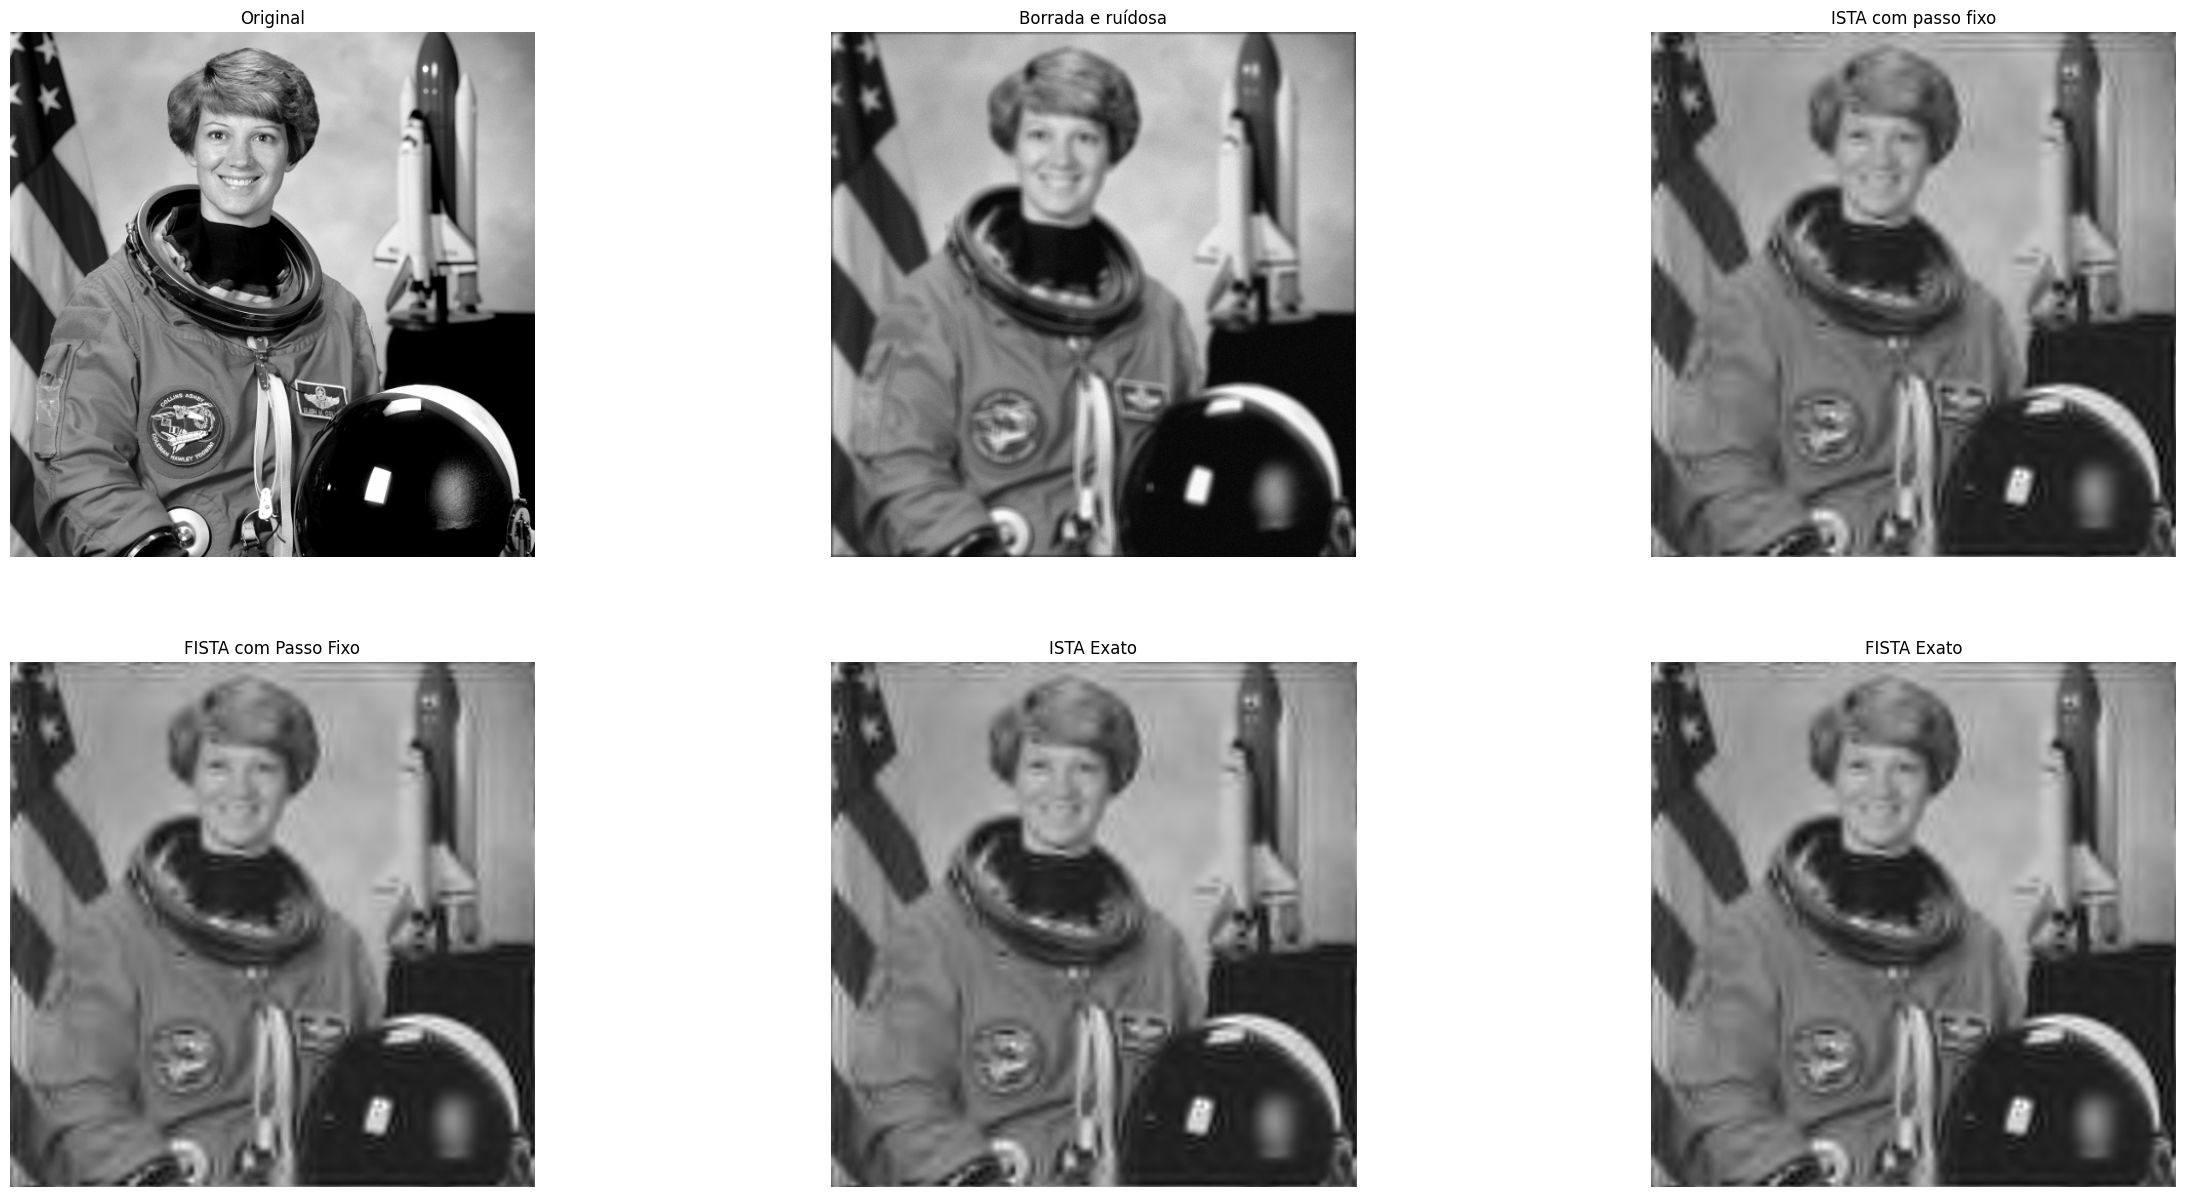

In [14]:
plt.figure( figsize = ( 30, 15 ) )

plt.subplot( 2, 3, 1 )
plt.imshow( img, cmap = plt.cm.gray )
plt.axis( "off" )
plt.title( "Original" )

plt.subplot( 2, 3, 2 )
plt.imshow( b, cmap = plt.cm.gray )
plt.axis( "off" )
plt.title( "Borrada e ruídosa" )

plt.subplot( 2, 3, 3 )
plt.imshow( iters_ista_fixo[ -1 ], cmap = plt.cm.gray )
plt.axis( "off" )
plt.title( "ISTA com passo fixo" )

plt.subplot( 2, 3, 4 )
plt.imshow( iters_fista_fixo[ -1 ], cmap = plt.cm.gray )
plt.axis( "off" )
plt.title( "FISTA com Passo Fixo" )

plt.subplot( 2, 3, 5 )
plt.imshow( iters_ista_exato[ -1 ], cmap = plt.cm.gray )
plt.axis( "off" )
plt.title( "ISTA Exato" )

plt.subplot( 2, 3, 6 )
plt.imshow( iters_fista_exato[ -1 ], cmap = plt.cm.gray )
plt.axis( "off" )
plt.title( "FISTA Exato" )

In [15]:
F_vals_ista_fixo = [ f( x ) + gamma * g( x, wav ) for x in iters_ista_fixo ]
F_vals_fista_fixo = [ f( x ) + gamma * g( x, wav ) for x in iters_fista_fixo ]
F_vals_ista_exato = [ f( x ) + gamma * g( x, wav ) for x in iters_ista_exato ]
F_vals_fista_exato = [ f( x ) + gamma * g( x, wav ) for x in iters_fista_exato ]


(np.float64(-50.0),
 np.float64(1050.0),
 np.float64(281.29298944678084),
 np.float64(44833.108025456786))

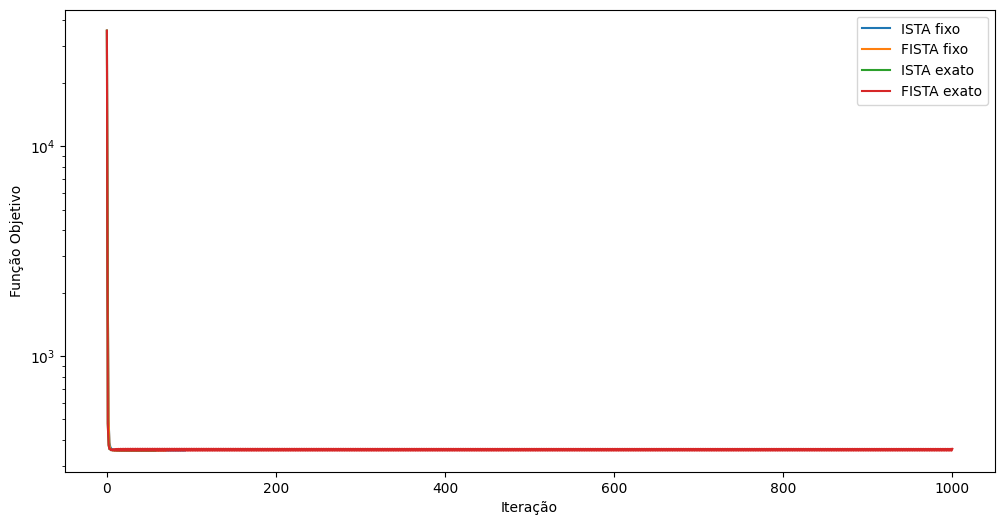

In [16]:
plt.figure( figsize = ( 12, 6 ) )
plt.semilogy( F_vals_ista_fixo )
plt.semilogy( F_vals_fista_fixo )
plt.semilogy( F_vals_ista_exato )
plt.semilogy( F_vals_fista_exato )
plt.legend( [ "ISTA fixo", "FISTA fixo", "ISTA exato", "FISTA exato" ] )
plt.xlabel( "Iteração" )
plt.ylabel( "Função Objetivo" )
plt.axis( "tight" )

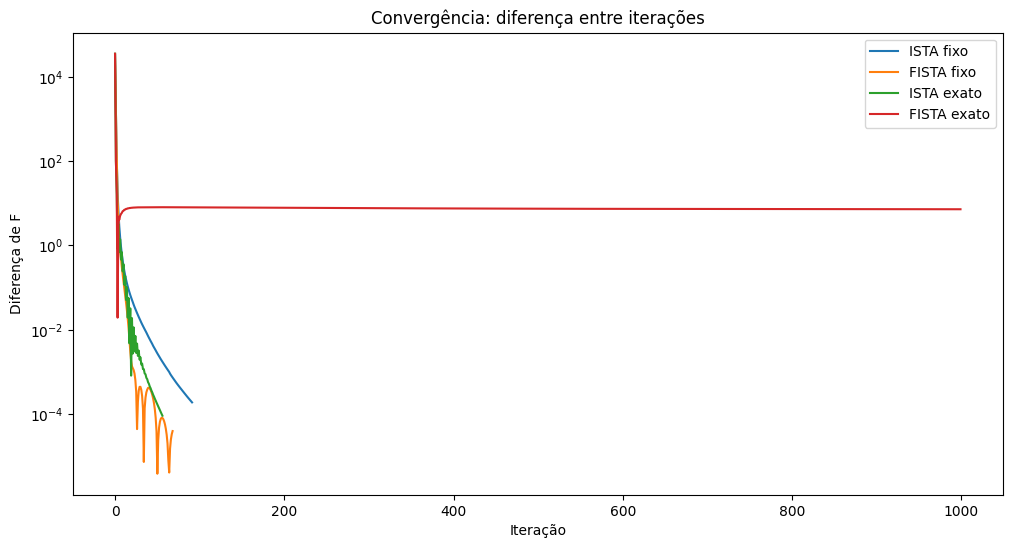

In [21]:
def delta_F( F_vals ):
    return [ abs( F_vals[ k ] - F_vals[ k-1 ] ) for k in range( 1, len( F_vals ) ) ]

delta_ista_fixo = delta_F( F_vals_ista_fixo )
delta_fista_fixo = delta_F( F_vals_fista_fixo )
delta_ista_exato = delta_F( F_vals_ista_exato )
delta_fista_exato = delta_F( F_vals_fista_exato )

plt.figure( figsize = ( 12,6 ) )
plt.semilogy( delta_ista_fixo )
plt.semilogy( delta_fista_fixo )
plt.semilogy( delta_ista_exato )
plt.semilogy( delta_fista_exato )
plt.legend( [ "ISTA fixo", "FISTA fixo", "ISTA exato", "FISTA exato" ] )
plt.xlabel( "Iteração" )
plt.ylabel( "Diferença de F" )
plt.title( "Convergência: diferença entre iterações" )
plt.show()


In [17]:
#numero de iterações
print( "Iterações ISTA fixo: ", len( iters_ista_fixo ) )
print( "Iterações FISTA fixo: ", len( iters_fista_fixo ) )
print( "Iterações ISTA exato: ", len( iters_ista_exato ) )
print( "Iterações ISTA exato: ", len( iters_fista_exato ) )

Iterações ISTA fixo:  93
Iterações FISTA fixo:  70
Iterações ISTA exato:  58
Iterações ISTA exato:  1001


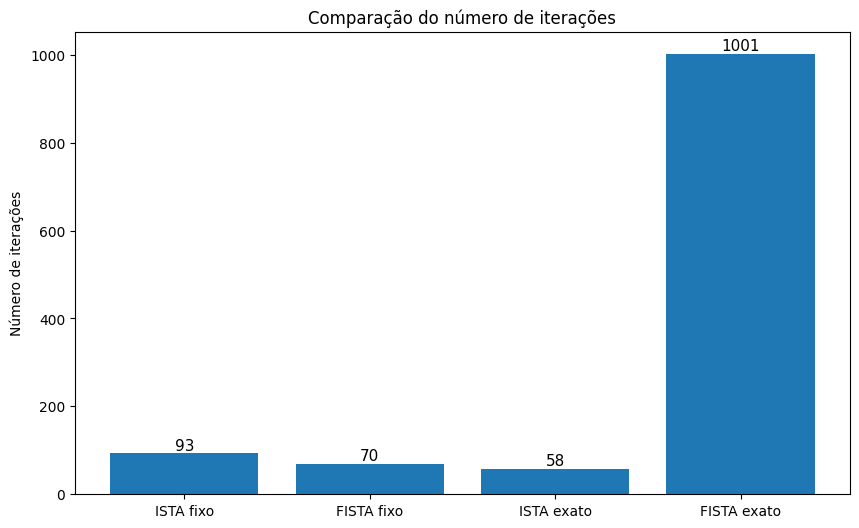

In [34]:
num_iters = [ len( iters_ista_fixo ), len( iters_fista_fixo ), len( iters_ista_exato ), len( iters_fista_exato ) ]
label = [ "ISTA fixo", "FISTA fixo", "ISTA exato", "FISTA exato" ]

plt.figure( figsize = ( 10,6 ) )
bars = plt.bar( label, num_iters )
plt.ylabel( "Número de iterações" )
plt.title( "Comparação do número de iterações" )

for bar in bars:
    height = bar.get_height()
    plt.text( bar.get_x() + bar.get_width()/2, height + 1, str( height ), ha = 'center', va = 'bottom', fontsize = 11 )

plt.show()


In [18]:
# valor da função objetivo na ultima iteração
print( "Função objetivo ISTA fixo: ", F_vals_ista_fixo[ -1 ] )
print( "Função objetivo FISTA fixo: ", F_vals_fista_fixo[ -1 ] )
print( "Função objetivo ISTA exato: ", F_vals_ista_exato[ -1 ] )
print( "Função objetivo FISTA exato: ", F_vals_fista_exato[ -1 ] )

Função objetivo ISTA fixo:  355.08736955914407
Função objetivo FISTA fixo:  355.0837376912607
Função objetivo ISTA exato:  355.0845142694935
Função objetivo FISTA exato:  361.6252275508397
